In [1]:
# Pré-requisito: Instalação das bibliotecas no ambiente virtual
!pip install python-bcb sidrapy pandas matplotlib seaborn --upgrade

In [2]:
# 1. Importação das bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bcb import sgs
import sidrapy

In [3]:
# Configuração do estilo visual para padrão acadêmico
sns.set_theme(style="whitegrid", palette="muted")

In [5]:
# 2. Coleta de Dados (Extração via APIs)
# Selic Meta (código SGS: 432) - Selecionando o período a partir de 2017
selic = sgs.get({'Selic': 432}, start='2017-01-01')

In [6]:
# IPCA Acumulado 12 meses (Tabela Sidra: 1737, Variável: 2265)
ipca_raw = sidrapy.get_table(table_code="1737", territorial_level="1", ibge_territorial_code="all", variable="2265", period="last 120")

In [7]:
# 3. Tratamento e Limpeza (Data Wrangling)
# Tratando o DataFrame do IPCA importado da API do IBGE
ipca = ipca_raw.iloc[1:].copy() # Remove a linha de cabeçalho descritivo
ipca['data'] = pd.to_datetime(ipca['D2C'], format='%Y%m') # Converte para datetime
ipca['IPCA'] = ipca['V'].astype(float) # Converte a string para ponto flutuante
ipca.set_index('data', inplace=True)
ipca = ipca[['IPCA']]

In [8]:
# Ajustando a frequência da Selic para mensal e padronizando os dias
selic_mensal = selic.resample('ME').last()
selic_mensal.index = selic_mensal.index.to_period('M').to_timestamp()

In [9]:
# Unindo as duas bases (Merge) e tratando valores nulos
df_conjuntura = pd.merge(ipca, selic_mensal, left_index=True, right_index=True)
df_conjuntura.dropna(inplace=True)

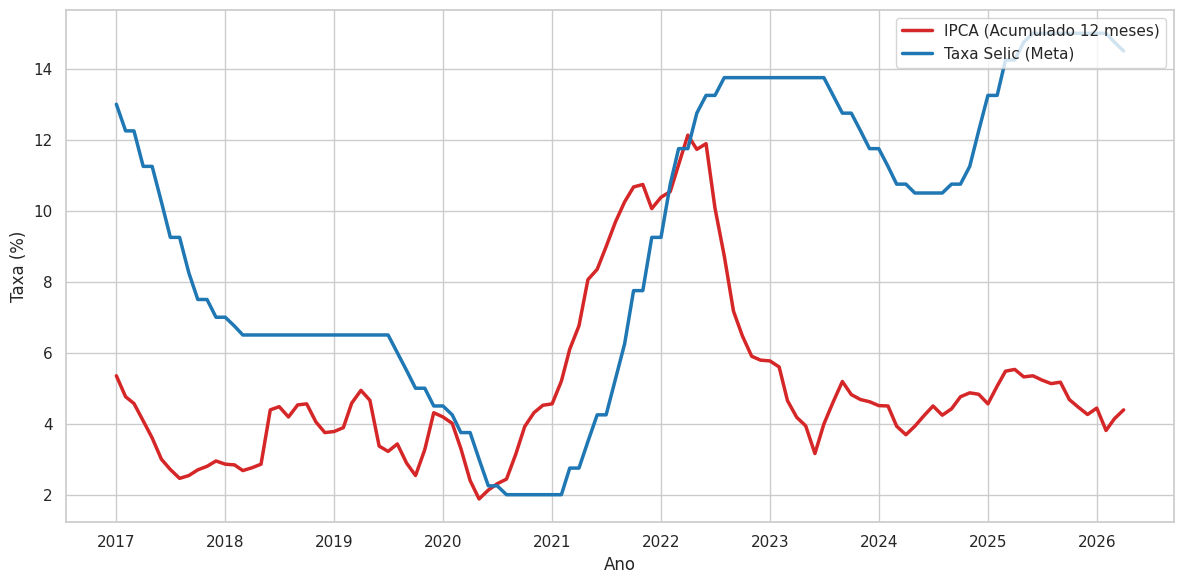

In [10]:
# 4. Geração do Gráfico (Visualização)
# Inicializa a figura e define as dimensões
plt.figure(figsize=(12, 6))

# Plota as séries temporais
plt.plot(df_conjuntura.index, df_conjuntura['IPCA'], label='IPCA (Acumulado 12 meses)', color='#d62728', linewidth=2.5)
plt.plot(df_conjuntura.index, df_conjuntura['Selic'], label='Taxa Selic (Meta)', color='#1f77b4', linewidth=2.5)

# Aplica as legendas dos eixos
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Taxa (%)', fontsize=12)

# Adiciona a legenda superior e renderiza a visualização final
plt.legend(loc='upper right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()